# Problema de valores propios en 2D con elementos finitos

Queremos resolver el problema de valores propios
dado por la ecuación de Helmholtz

$$\nabla^2 u(\mathbf{x}) = -\lambda^2 u(\mathbf{x})\quad \forall \mathbf{x}\in \Omega \, ,$$

con

$$u(\mathbf{x}) = 0\quad \forall \mathbf{x} \in \partial\Omega\, .$$

Vamos a usar una solución aproximada de la forma

$$u(\mathbf{x}) = \sum_{n=0}^{N} u_n \phi_n(\mathbf{x})\, .$$

Si usamos el método de Galerkin, la ecuación diferencial es equivalente
al siguiente problema variacional

$$\int\limits_\Omega (\nabla u) \cdot (\nabla \phi_n) d\Omega
= \lambda^2\int\limits_\Omega  u \phi_n d\Omega\, \quad \forall \phi_n\, .$$

Si remplazamos $u(x)$ en este sistema obtenemos

$$\sum_{j=0}^N \left[\int\limits_\Omega (\nabla \phi_i) \cdot (\nabla \phi_j) d\Omega\right] u_j
= \lambda^2 \sum_{j=0}^N \left[\int\limits_\Omega \phi_i \phi_j dx\right] u_j\, .$$

Esto lleva al siguiente sistema de ecuaciones

$$[K]\{\mathbf{u}\} = \lambda^2[M]\{\mathbf{u}\}$$

Usando triángulos lineales, las matrices de rigidez y masa son

$$K_\text{local} =  \frac{|J|}{2} (J^{-1}D)^T (J^{-1}D)\, ,$$

y

$$M_\text{local} = \frac{|J|}{24}
\begin{bmatrix}
2 & 1 & 1\\
1 & 2 & 1\\
1 & 1 & 2\end{bmatrix}\, ,$$

donde $|J|$ es el determinante jacobiano.

<div class="alert alert-warning">

Acá estamos dejando por fuera muchos detalles del ensamblaje de la
matriz y del mapeo del ordenamiento local al global.
</div>

In [1]:
%matplotlib widget

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eigh
import meshio

In [3]:
# Configuracion graficos
gris = '#757575'
plt.rcParams["mathtext.fontset"] = "cm"
plt.rcParams["text.color"] = gris
plt.rcParams["font.size"] = 12
plt.rcParams["xtick.color"] = gris
plt.rcParams["ytick.color"] = gris
plt.rcParams["axes.labelcolor"] = gris
plt.rcParams["axes.edgecolor"] = gris
plt.rcParams["axes.spines.right"] = False
plt.rcParams["axes.spines.top"] = False

In [4]:
def assem(coords, elems):
    """
    Ensambla las matrice de rigidez y masa
    
    Parámetros
    ----------
    coords : ndarray, float
        Coordenadas de los nodos.
    elems : ndarray, int
        Conectividad de los elementos.
    
    Retorna
    -------
    stiff : ndarray, float
        Matriz de rigidez del problema.
    mass : ndarray, float
        Matriz de masa del problema.
    """
    ncoords = coords.shape[0]
    stiff = np.zeros((ncoords, ncoords))
    mass = np.zeros((ncoords, ncoords))
    for el_cont, elem in enumerate(elems):
        stiff_loc, mass_loc = local_mat(coords[elem])
        for row in range(3):
            for col in range(3):
                row_glob, col_glob = elem[row], elem[col]
                stiff[row_glob, col_glob] += stiff_loc[row, col]
                mass[row_glob, col_glob] += mass_loc[row, col]
    return stiff, mass

In [5]:
def local_mat(coords):
    """Calcula la matriz de rigidez local
        
    Parámetros
    ----------
    coords : ndarray, float
        Coordenadas de los nodos del elemento.
    
    Retorna
    -------
    stiff : ndarray, float
        Matriz de rigidez local.
    mass : float
        Matriz de masa local.
    """
    dNdr = np.array([
            [-1, 1, 0],
            [-1, 0, 1]])
    jaco = dNdr @ coords
    det = np.linalg.det(jaco)
    jaco_inv = np.linalg.inv(jaco)
    dNdx = jaco_inv @ dNdr
    stiff = 0.5 * det * (dNdx.T @ dNdx)
    mass = det/24 * np.array([
            [2.0, 1.0, 1.0],
            [1.0, 2.0, 1.0],
            [1.0, 1.0, 2.0]])
    return stiff, mass

In [6]:
def pts_restringidos(coords, malla, lineas_rest):
    """
    Identifica los nodos restringidos y libres
    para la malla.
        
    Parámetros
    ----------
    coords : ndarray, float
        Coordenadas de los nodos del elemento.
    malla : Meshio mesh
        Objeto de malla de Meshio.
    lineas_rest : list
        Lista con los números para las líneas
        restringidas.
    
    Retorna
    -------
    pts_rest : list
        Lista de puntos restringidos.
    pts_libres : list
        Lista de puntos libres.
    """
    lineas = [malla.cells[k].data for k in lineas_rest]
    pts_rest = []
    for linea in lineas:
        pts_rest += set(linea.flatten())
    pts_libres = list(set(range(coords.shape[0])) - set(pts_rest))
    return pts_rest, pts_libres

## Ejemplo

En este caso leemos una malla de Gmsh usando ``meshio``.

In [7]:
malla = meshio.read("cuadrado51.msh")

Para este ejemplo los triángulos están en la
posición ``4`` de las celdas de la malla.

In [8]:
pts = malla.points
x, y = pts[:, 0:2].T
tri = malla.cells[4].data

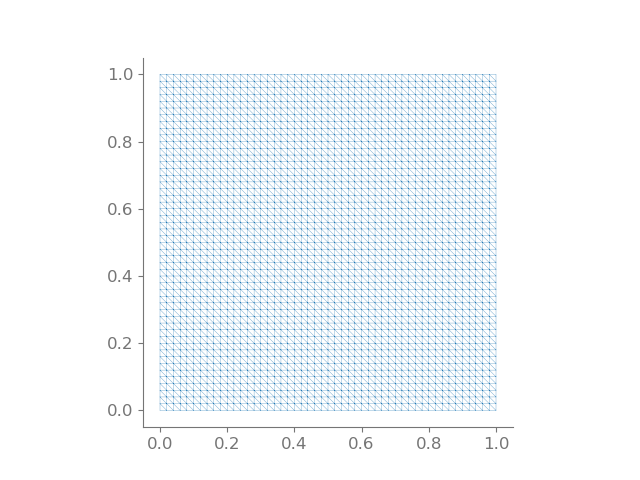

In [9]:
plt.figure()
plt.triplot(x, y, tri, linewidth=0.2)
plt.axis("image")
plt.show()

Para este caso, la solución analítica del problema es

$$u_{nm} = \sin(m \pi x)\sin(n \pi y)\, ,\quad \lambda_{mn}^2 = \pi^2(m^2 + n^2) \, .$$

In [10]:
stiff, mass = assem(pts[:, :2], tri)

Tenemosuna función que nos permite identificar los nodos
que están restringidos y los que están libres.

In [11]:
pts_rest, pts_libres = pts_restringidos(pts, malla, [0, 1, 2, 3])

Y resolvemos.

In [12]:
nvals = 36
vals, vecs = eigh(stiff[np.ix_(pts_libres, pts_libres)],
                  mass[np.ix_(pts_libres, pts_libres)],
                  subset_by_index=(0, nvals - 1))

In [13]:
np.round(vals, 4)

array([ 19.7587,  49.4318,  49.4787,  79.2682,  99.0794,  99.0803,
       128.8894, 129.286 , 168.8153, 168.841 , 179.2169, 199.1062,
       199.1268, 248.916 , 250.4805, 258.9748, 258.9756, 289.5472,
       289.6882, 320.6545, 340.7656, 340.9578, 369.8642, 369.8875,
       400.948 , 400.9598, 410.4671, 414.7984, 452.692 , 453.1369,
       501.9583, 501.9642, 504.6779, 525.6272, 526.7055, 533.504 ])

Y podemos comparar esto con la solución analítica

In [14]:
vals_ex = [(m**2 + n**2) * np.pi**2
                    for m in range(1, 10)
                    for n in range(1, 10)]
vals_ex = np.sort(vals_ex)[:nvals]
np.round(vals_ex, 4)

array([ 19.7392,  49.348 ,  49.348 ,  78.9568,  98.696 ,  98.696 ,
       128.3049, 128.3049, 167.7833, 167.7833, 177.6529, 197.3921,
       197.3921, 246.7401, 246.7401, 256.6097, 256.6097, 286.2185,
       286.2185, 315.8273, 335.5665, 335.5665, 365.1754, 365.1754,
       394.7842, 394.7842, 404.6538, 404.6538, 444.1322, 444.1322,
       493.4802, 493.4802, 493.4802, 513.2194, 513.2194, 523.089 ])

Text(0, 0.5, '$\\lambda_{mn}^2$')

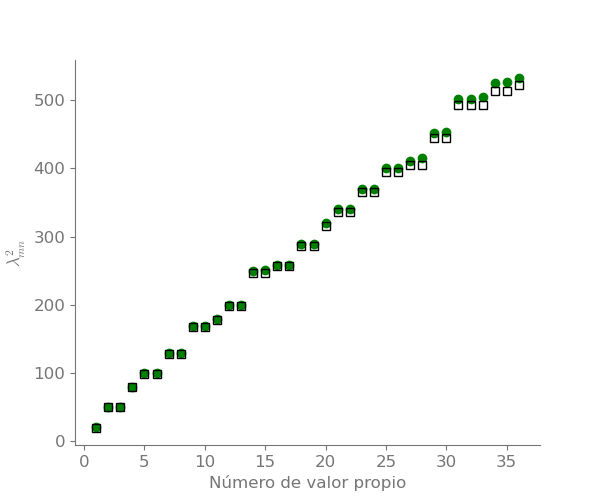

In [15]:
plt.figure(figsize=(6, 5))
plt.plot(range(1, nvals + 1), vals, "o", color="green")
plt.plot(range(1, nvals + 1), vals_ex, "s", mec="black",
         mfc="#FFFFFF00")
plt.xlabel("Número de valor propio")
plt.ylabel(r"$\lambda_{mn}^2$")

Miremos ahora uno de los vectores propios.

In [16]:
sol_c = np.zeros(pts.shape[0])
sol_c[pts_libres] = vecs[:, 10]

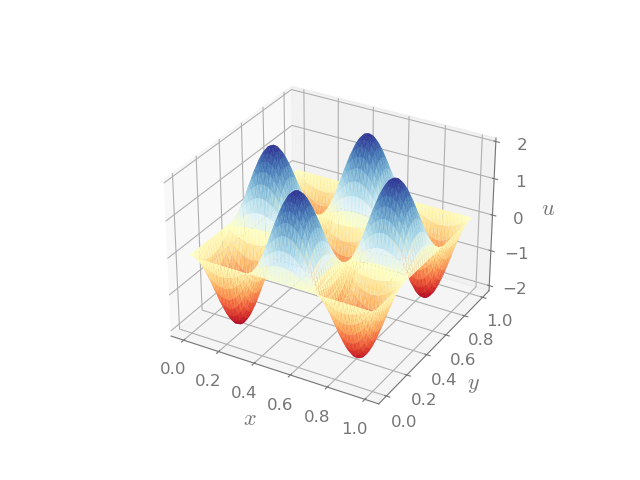

In [17]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.plot_trisurf(x, y, sol_c, triangles=tri, cmap="RdYlBu")
ax.set_xlabel(r"$x$", fontsize=16)
ax.set_ylabel(r"$y$", fontsize=16)
ax.set_zlabel(r"$u$", fontsize=16)
plt.show()